# Model comparison on evaluation set

In this notebook, we evaluate the different models' performance on the evaluation set, and compare with a baseline model. These models are:

- Baseline: a dummy classifier with stratified
- Logistic regressors (with and without synopsis embeddings)
- XGB ranker (with and without synopsis embeddings)
- LGBM ranked model added

Each has been trained in Jupyter Notebook files found in the models folder.


In [1]:
import numpy as np
import csv
import pandas as pd
import json
import matplotlib.pyplot as plt
import sklearn
import sys
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe

sys.path.append("../models")


In [2]:
## import test set

books_test = pd.read_csv('../data/books_engineered_test.csv')
books_test = books_test.copy()

In [3]:
books_test.groupby('release_year')['target'].sum()

release_year
2015    13
2016    25
2017    24
2018    22
2019    24
2020    20
2021    21
2022    21
2023    20
2024    24
2025    20
Name: target, dtype: int64

In [4]:
model_results = {}

In [5]:
## import trained models
import joblib 

dummy_classifier = joblib.load('../models/trained_models/dummy_model.pkl')

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

dummy_pred = dummy_classifier.predict(books_test[features])

# books_test['dummy_pred'] = dummy_pred

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, ndcg_score, recall_score, average_precision_score

model_results['dummy_classifier'] = {
    'f1_score': f1_score(books_test['target'], dummy_pred),
    'precision': precision_score(books_test['target'], dummy_pred),
    'recall': recall_score(books_test['target'], dummy_pred)

    # add more
}

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: T

In [6]:
# compare with baseline model of predicting books with previously-nominated authors

nom_pred = (books_test['NomineeBefore']).astype(int)

model_results['prior_nomination_baseline'] = {
    'f1_score': f1_score(books_test['target'], nom_pred),
    'precision': precision_score(books_test['target'], nom_pred),
    'recall': recall_score(books_test['target'], nom_pred)

    # add more
}

In [7]:
logistic_reg = joblib.load('../models/trained_models/logistic_model.pkl')

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

## for logistic model, need to fill NaN values with dummy values
books_test_log = books_test.copy()
books_test_log['years_since_last_nomination'] = books_test_log['years_since_last_nomination'].fillna(99)
books_test_log['month_of_publication'] = books_test_log['month_of_publication'].fillna('Unknown')

logistic_proba = logistic_reg.predict_proba(books_test_log[features])[:, 1]

# recover the weighted mean threshold to use for classification: 
thresholds = logistic_reg.cv_results_['thresholds']
scores = logistic_reg.cv_results_['scores']

weighted_mean_threshold = np.average(thresholds, weights=scores)

logistic_pred = (logistic_proba > weighted_mean_threshold).astype(int)

# books_test['logistic_pred'] = logistic_pred

model_results['logistic_reg'] = {
    'f1_score': f1_score(books_test['target'], logistic_pred),
    'precision': precision_score(books_test['target'], logistic_pred),
    'recall': recall_score(books_test['target'], logistic_pred)
    # add more
}

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: T

In [8]:
xgbranker = joblib.load('../models/trained_models/xgbranker_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_ranking = xgbranker.predict(books_test[features])

books_test['xgb_rank_score'] = xgb_ranking

books_test['rank_within_year'] = books_test.groupby('release_year')['xgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (books_test['rank_within_year'] <= num_finalists).astype(int)
top10 = (books_test['rank_within_year'] <= 10).astype(int)
top15 = (books_test['rank_within_year'] <= 15).astype(int)
top20 = (books_test['rank_within_year'] <= 20).astype(int)
top100 = (books_test['rank_within_year'] <= 100).astype(int)

model_results['xgb_ranker'] = {
    'f1_score': f1_score(books_test['target'], topk),
    'precision': precision_score(books_test['target'], topk),
    'recall': recall_score(books_test['target'], topk),
    'precision@10': precision_score(books_test['target'], top10),
    'precision@15': precision_score(books_test['target'], top15),
    'precision@20': precision_score(books_test['target'], top20),
    # add more
}

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: T

In [9]:
xgbclassifier= joblib.load('../models/trained_models/xgbclassifier_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_predict = xgbclassifier.predict(books_test[features])

model_results['xgb_classifier'] = {
    'f1_score': f1_score(books_test['target'], xgb_predict),
    'precision': precision_score(books_test['target'], xgb_predict),
    'recall': recall_score(books_test['target'], xgb_predict),
    # add more
}

In [10]:
# the pickled lgbm pipeline references bool_to_int from the training notebook,
# so it must be defined here before joblib.load can unpickle it
def bool_to_int(x):
    return x.astype(int)

lgbmranker = joblib.load('../models/trained_models/lgbmranker_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

lgb_ranking = lgbmranker.predict(books_test[features])

books_test['lgb_rank_score'] = lgb_ranking

books_test['lgb_rank_within_year'] = books_test.groupby('release_year')['lgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (books_test['lgb_rank_within_year'] <= num_finalists).astype(int)
top10 = (books_test['lgb_rank_within_year'] <= 10).astype(int)
top15 = (books_test['lgb_rank_within_year'] <= 15).astype(int)
top20 = (books_test['lgb_rank_within_year'] <= 20).astype(int)

# NDCG@k, computed per year then averaged (as in models/lgbm_ranker.ipynb)
def mean_ndcg_at_k(data, score_column, k):
    ndcg_at_k_list = []
    for yr, grp in data.groupby('release_year'):
        y_true = grp['target'].values.astype(int)
        y_score = grp[score_column].values
        if y_true.sum() == 0:
            continue  # no finalists this year, metric undefined
        ndcg_at_k_list.append(ndcg_score([y_true], [y_score], k=k))
    return np.mean(ndcg_at_k_list)

model_results['lgbm_ranker'] = {
    'f1_score': f1_score(books_test['target'], topk),
    'precision': precision_score(books_test['target'], topk),
    'recall': recall_score(books_test['target'], topk),
    'precision@10': precision_score(books_test['target'], top10),
    'precision@15': precision_score(books_test['target'], top15),
    'precision@20': precision_score(books_test['target'], top20),
    'ndcg@k': mean_ndcg_at_k(books_test, 'lgb_rank_score', num_finalists),
    'ndcg@10': mean_ndcg_at_k(books_test, 'lgb_rank_score', 10),
    'ndcg@15': mean_ndcg_at_k(books_test, 'lgb_rank_score', 15),
    'ndcg@20': mean_ndcg_at_k(books_test, 'lgb_rank_score', 20),
    # add more
}

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'dummy_classifier'),
  Text(1, 0, 'prior_nomination_baseline'),
  Text(2, 0, 'logistic_reg'),
  Text(3, 0, 'xgb_ranker'),
  Text(4, 0, 'xgb_classifier'),
  Text(5, 0, 'lgbm_ranker')])

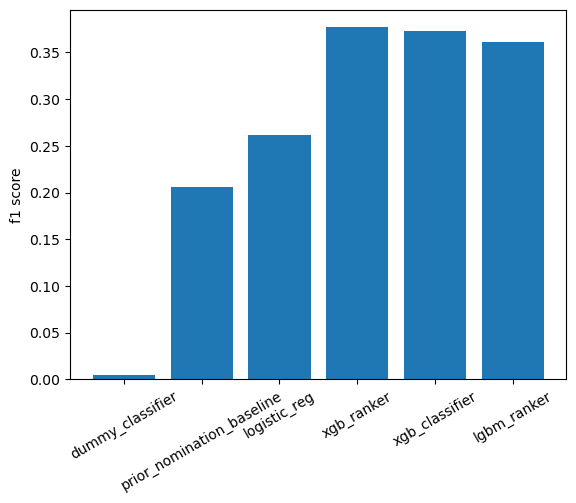

In [11]:
plt.bar(list(model_results), [model['f1_score'] for model in model_results.values()])
plt.ylabel('f1 score')
plt.xticks(rotation=30)

Text(0, 0.5, 'score')

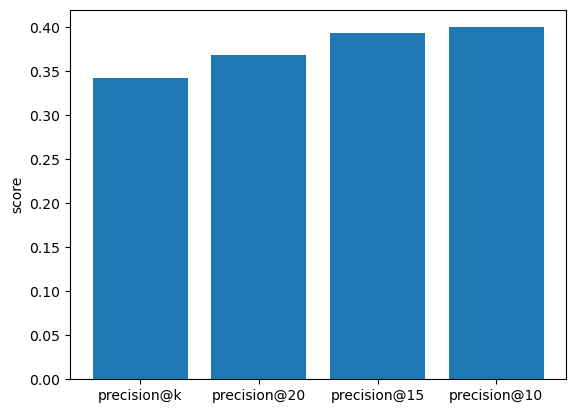

In [12]:
plt.bar(['precision@k', 'precision@20', 'precision@15', 'precision@10'],
    [model_results['xgb_ranker'][p] for p in ['precision', 'precision@20', 'precision@15', 'precision@10']]
)
plt.ylabel('score')

Text(0.5, 1.0, 'lgbm_ranker NDCG on test set')

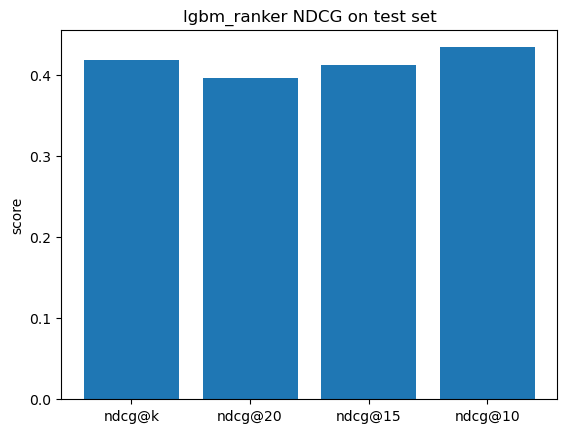

In [13]:
plt.bar(['ndcg@k', 'ndcg@20', 'ndcg@15', 'ndcg@10'],
    [model_results['lgbm_ranker'][n] for n in ['ndcg@k', 'ndcg@20', 'ndcg@15', 'ndcg@10']]
)
plt.ylabel('score')
plt.title('lgbm_ranker NDCG on test set')

In [14]:
f1scores = []
years = []

for year, group in books_test.groupby('release_year'):
    xgb_ranking = xgbranker.predict(group[features])

    group['xgb_rank_score'] = xgb_ranking

    group['rank_within_year'] = group.groupby('release_year')['xgb_rank_score'].rank(
            method='first', 
            ascending=False
        )

    # in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
    # so, set number of finalists to 26 per year and mark top 26 books as correct
    num_finalists = 26

    topk = (group['rank_within_year'] <= num_finalists).astype(int)
    f1scores.append(f1_score(group['target'], topk))
    years.append(year)


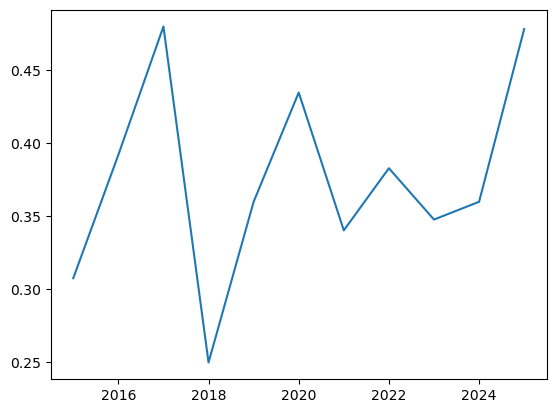

In [15]:
plt.plot(years, f1scores)




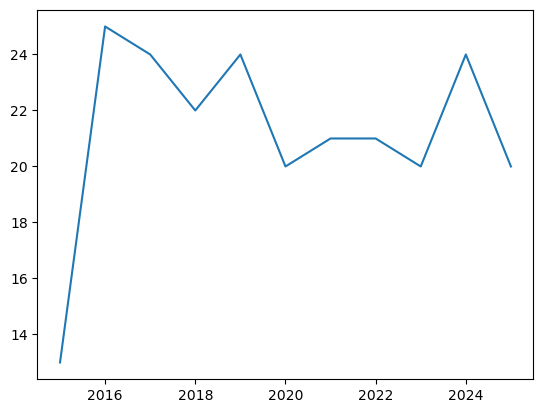

In [16]:
plt.plot(years, books_test.groupby('release_year')['target'].sum().values)


<Axes: >

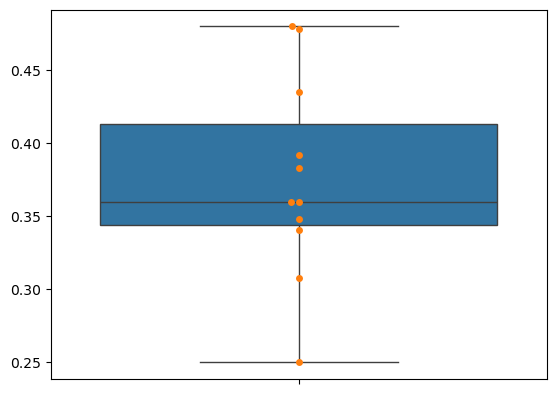

In [17]:
import seaborn as sns

ax = sns.boxplot(data=f1scores)

sns.swarmplot(data=f1scores)

<Axes: >

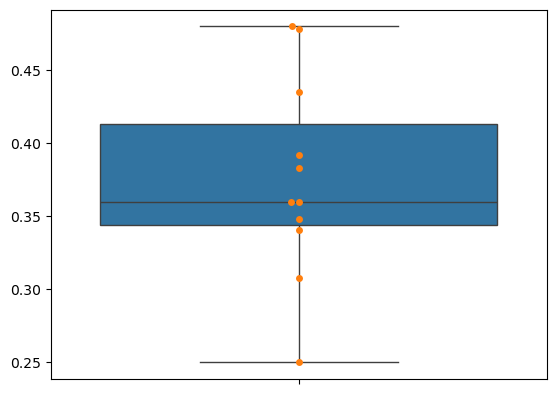

In [18]:
import seaborn as sns

ax = sns.boxplot(data=f1scores)

sns.swarmplot(data=f1scores)